In [1]:
data_dir = r"C:\Tutorial\Visuara\Computer vision from Scratch\flowers"

In [2]:
import sys
print(sys.executable)

C:\PYTHON_ENV\env_object_detection\Scripts\python.exe


In [3]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\PYTHON_ENV\env_object_detection\Scripts\python.exe -m pip install --upgrade pip


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision import models
from torchsummary import summary
import wandb
import os

In [5]:
# =======================
# STEP 0: Initialize wandb
# =======================
wandb.init(project="MobileNet-flowers-v2", config={
    "epochs": 20,
    "batch_size": 16,
    "learning_rate": 0.001,
    "architecture": "MobileNet",
    "pretrained": True,
    "input_size": 224
})

# Shortcut to config values
config = wandb.config

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\sangr\_netrc.
wandb: Currently logged in as: sangram01 (sangram01-srm-institute-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [6]:
# =======================
# STEP 1: Data Preparation
# =======================

# Transforms for training and validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dir = r"C:\Tutorial\Visuara\Computer vision from Scratch\flowers/train"
val_dir = r"C:\Tutorial\Visuara\Computer vision from Scratch\flowers/val"

train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(root=val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size)

In [9]:
# ===========================
# STEP 2: Load Pretrained MobileNetV2
# ===========================
from torchvision.models import MobileNet_V2_Weights

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

# Replace the final classifier layer for 5-class flower classification
model.classifier[1] = nn.Linear(model.last_channel, 5)

# Freeze all parameters except the final layer
for param in model.parameters():
    param.requires_grad = False
for param in model.classifier[1].parameters():
    param.requires_grad = True

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Watch the model's weights and gradients with wandb
wandb.watch(model, log="all", log_freq=10)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to C:\Users\sangr/.cache\torch\hub\checkpoints\mobilenet_v2-7ebf99e0.pth


100%|█████████████████████████████████████████████████████████████████████████████| 13.6M/13.6M [00:00<00:00, 33.5MB/s]


In [10]:
# ===================
# STEP 3: Loss & Optimizer
# ===================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

In [11]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            batch_correct = (preds == labels).sum().item()
            train_correct += batch_correct
            train_total += labels.size(0)

            # Print every 10 batches
            if (i + 1) % 10 == 0:
                batch_acc = batch_correct / labels.size(0)
                print(f"[Batch {i+1}/{len(train_loader)}] Loss: {loss.item():.4f}, Batch Acc: {batch_acc:.4f}")

        train_acc = train_correct / train_total
        wandb.log({"epoch": epoch + 1, "train_loss": running_loss, "train_accuracy": train_acc})
        print(f"Epoch {epoch+1} Summary - Loss: {running_loss:.4f}, Train Accuracy: {train_acc:.4f}")

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        wandb.log({"epoch": epoch + 1, "val_accuracy": val_acc})
        print(f"Validation Accuracy: {val_acc:.4f}")


In [12]:
# ===================
# Train the model
# ===================
train_model(model, criterion, optimizer, train_loader, 
            val_loader, epochs=config.epochs)


Epoch 1/20
------------------------------
[Batch 10/251] Loss: 1.4839, Batch Acc: 0.1250
[Batch 20/251] Loss: 1.1891, Batch Acc: 0.7500
[Batch 30/251] Loss: 1.0958, Batch Acc: 0.7500
[Batch 40/251] Loss: 1.0311, Batch Acc: 0.7500
[Batch 50/251] Loss: 1.0755, Batch Acc: 0.6250
[Batch 60/251] Loss: 0.8590, Batch Acc: 0.7500
[Batch 70/251] Loss: 0.9175, Batch Acc: 0.7500
[Batch 80/251] Loss: 0.9622, Batch Acc: 0.6250
[Batch 90/251] Loss: 0.6994, Batch Acc: 0.8750
[Batch 100/251] Loss: 0.8119, Batch Acc: 0.7500
[Batch 110/251] Loss: 0.7666, Batch Acc: 0.7500
[Batch 120/251] Loss: 0.6527, Batch Acc: 0.8750
[Batch 130/251] Loss: 0.8108, Batch Acc: 0.6250
[Batch 140/251] Loss: 0.4633, Batch Acc: 0.8750
[Batch 150/251] Loss: 0.5745, Batch Acc: 0.8125
[Batch 160/251] Loss: 0.8860, Batch Acc: 0.7500
[Batch 170/251] Loss: 0.4980, Batch Acc: 0.9375
[Batch 180/251] Loss: 0.7351, Batch Acc: 0.6250
[Batch 190/251] Loss: 0.4933, Batch Acc: 0.8750
[Batch 200/251] Loss: 0.4460, Batch Acc: 0.8750
[Batch

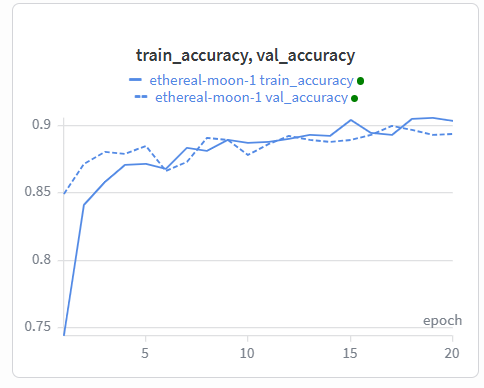